# NDT7 EDA — ฟิลิปปินส์: เมืองหลวง vs ต่างจังหวัด

เล่มนี้แยกออกมาจาก `ndt7_ph_main.ipynb` (ซึ่งเล่าเรื่องระดับ **region** 17 หน่วย) เพราะเป็นคนละคำถามวิจัย —
ที่นี่โฟกัส **ความเหลื่อมล้ำระหว่างเขตเมืองหลวงกับส่วนที่เหลือของประเทศ** และการจัดอันดับรายจังหวัด

- **Metro Manila** = `province = 'MetropolitanManila'` (GADM ADM1 ยุบ NCR ทั้ง 4 เขตเป็นหน่วยเดียว = เขตเมืองหลวงทั้งก้อน)
  ซึ่งกินข้อมูล **109.5M แถว ≈ 42% ของทั้งประเทศ** — เยอะขนาดที่ว่าถ้าเอาไปวางเรียงกับอีก 79 จังหวัดในกราฟเดียว
  มันจะบิดค่าเฉลี่ยข้ามจังหวัดจนอ่านไม่ได้ การแยกมาเทียบ 1-ต่อ-ที่เหลือแบบนี้จึงตรงกว่า
- **Rest of PH** = ทุกจังหวัดที่เหลือรวมกัน
- ใช้ข้อมูลชุดเดียวกับเล่มหลัก: `data/ph/mlab_ph_clean.parquet` (262M แถว, สร้างโดย `mlab_ph_clean_v2.ipynb`)

## Part 0 · Setup

เหมือนเล่มหลักทุกอย่าง (path แบบไม่ขึ้นกับ working directory, DuckDB view ชื่อ `t`, helper `q()`, สี fixed/mobile)
บวกด้วยนิยาม `AREA` = Metro Manila / Rest of PH ที่ใช้ซ้ำทั้งเล่ม

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- resolve repo root regardless of the kernel's working dir ---
ROOT = Path.cwd()
while not (ROOT / 'data' / 'ph').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

CLEAN = ROOT / 'data' / 'ph' / 'mlab_ph_clean.parquet'
assert CLEAN.exists(), f'missing {CLEAN}'

con = duckdb.connect()
con.execute("SET max_memory='12GB'")
con.execute(f"SET temp_directory='{(ROOT / '.tmp').as_posix()}'")   # spill to disk instead of OOM
# --- exclude one monitoring/bot client IP (865k tests, dominated SultanKudarat). Part 3 below
#     documents it and therefore reads the UNFILTERED `t_raw`; everything else uses filtered `t`. ---
FLOOD_IPS = ('58.69.220.245',)
_flood = ', '.join(f"'{ip}'" for ip in FLOOD_IPS)
con.execute(f"CREATE OR REPLACE VIEW t_raw AS SELECT * FROM read_parquet('{CLEAN.as_posix()}')")
con.execute(f"CREATE OR REPLACE VIEW t AS SELECT * FROM read_parquet('{CLEAN.as_posix()}') "
            f"WHERE client_ip NOT IN ({_flood})")

def q(sql):
    """Run SQL against the cleaned PH dataset (exposed as view `t`) and return a DataFrame."""
    return con.execute(sql).df()

# --- reusable SQL predicates = the analysis vocabulary (same as the main notebook) ---
FIXED  = "network_type = 'broadband'"
MOBILE = "network_type = 'cellular'"
DL     = "type = 'download'"
UL     = "type = 'upload'"

# --- the split this notebook is built around ---
MANILA = "MetropolitanManila"
AREA   = f"CASE WHEN province = '{MANILA}' THEN 'Metro Manila' ELSE 'Rest of PH' END"
AREAS  = ['Metro Manila', 'Rest of PH']

# min tests per province before it may enter a ranking. Set from the actual n distribution:
# fixed median n = 113k but the thin tail goes down to Apayao at 61 tests; mobile is far
# sparser (median 6.2k), so it needs a looser bar or the ranking has too few provinces left.
MIN_TESTS = {'broadband': 10_000, 'cellular': 5_000}

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})
C_FIXED, C_MOBILE = '#0B6E5C', '#B8571F'
C_AREA = {'Metro Manila': '#7B3FA0', 'Rest of PH': '#8C8C8C'}

split = q(f"""
    SELECT {AREA} AS area, COUNT(*) AS tests, COUNT(DISTINCT province) AS provinces
    FROM t WHERE province IS NOT NULL GROUP BY 1
""")
split['pct'] = (100 * split.tests / split.tests.sum()).round(1)
print(f'ROOT  : {ROOT}')
print(split.to_string(index=False))

ROOT  : E:\ndt7
        area     tests  provinces  pct
Metro Manila 109090611          1 41.8
  Rest of PH 152155073         79 58.2


# Part 1 · ช่องว่างเมืองหลวง–ต่างจังหวัด

ภาพหลักของเล่ม: Metro Manila เร็วกว่าส่วนที่เหลือของประเทศแค่ไหน

- **panel ซ้าย/กลาง:** ความเร็ว download แยก fixed vs mobile ทำทั้ง **mean** และ **median**
  (mean สูงกว่า median = การแจกแจงเบ้ขวา มี connection เร็ว ๆ ลากค่าเฉลี่ยขึ้น)
- **panel ขวา:** *mobile reliance* = สัดส่วน test ที่เป็น mobile — ยิ่งสูงยิ่งบ่งว่าพื้นที่นั้นพึ่งมือถือเพราะเน็ตบ้านเข้าไม่ถึง
- ตัวเลข **gap** ใต้กราฟคิดเป็น % ที่ Manila เร็วกว่า (`(manila − rest) / rest × 100`)

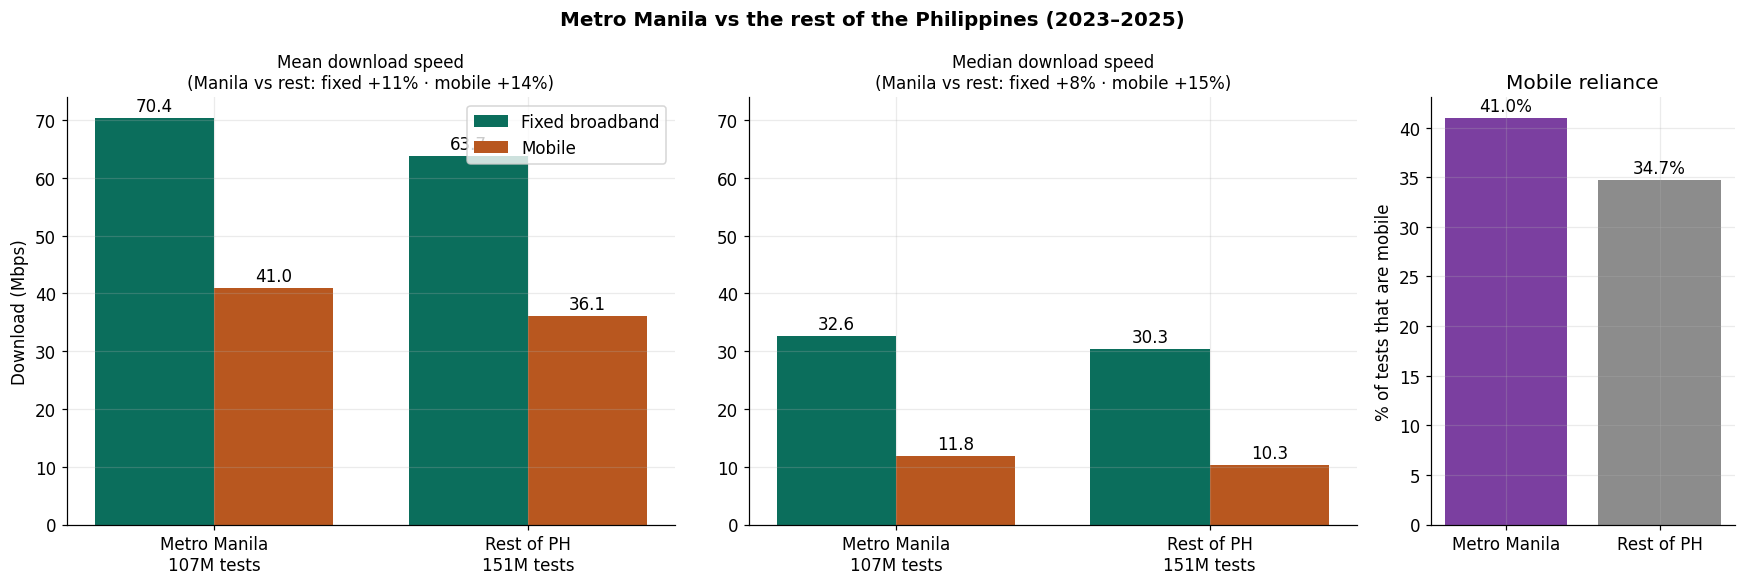

,area,tests,mobile_reliance_pct,fixed_mean,fixed_med,mobile_mean,mobile_med
0,Metro Manila,106972329,41.0,70.4,32.6,41.0,11.8
1,Rest of PH,150526723,34.7,63.7,30.3,36.1,10.3


In [2]:
gap = q(f"""
    SELECT {AREA} AS area,
           COUNT(*) AS tests,
           ROUND(100.0*SUM(CASE WHEN {MOBILE} THEN 1 ELSE 0 END)/COUNT(*), 1) AS mobile_reliance_pct,
           ROUND(AVG(CASE    WHEN {FIXED}  AND {DL} THEN mean_throughput_mbps END), 1) AS fixed_mean,
           ROUND(MEDIAN(CASE WHEN {FIXED}  AND {DL} THEN mean_throughput_mbps END), 1) AS fixed_med,
           ROUND(AVG(CASE    WHEN {MOBILE} AND {DL} THEN mean_throughput_mbps END), 1) AS mobile_mean,
           ROUND(MEDIAN(CASE WHEN {MOBILE} AND {DL} THEN mean_throughput_mbps END), 1) AS mobile_med
    FROM t
    WHERE province IS NOT NULL AND ({FIXED} OR {MOBILE})
    GROUP BY 1
""").set_index('area').loc[AREAS].reset_index()

x, w = np.arange(2), 0.38
fig, (axm, axmd, axr) = plt.subplots(1, 3, figsize=(16, 5.4),
                                     gridspec_kw={'width_ratios': [2, 2, 1]})

for ax, fcol, mcol, ttl in [(axm, 'fixed_mean', 'mobile_mean', 'Mean'),
                            (axmd, 'fixed_med', 'mobile_med', 'Median')]:
    b1 = ax.bar(x - w/2, gap[fcol], w, label='Fixed broadband', color=C_FIXED)
    b2 = ax.bar(x + w/2, gap[mcol], w, label='Mobile', color=C_MOBILE)
    ax.bar_label(b1, fmt='%.1f', padding=2)
    ax.bar_label(b2, fmt='%.1f', padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{r.area}\n{r.tests/1e6:.0f}M tests' for _, r in gap.iterrows()])
    # % by which Manila beats the rest, per segment
    sub = [f'{c.split("_")[0]} {100*(gap[c][0]-gap[c][1])/gap[c][1]:+.0f}%' for c in (fcol, mcol)]
    ax.set_title(f'{ttl} download speed\n(Manila vs rest: {" · ".join(sub)})', fontsize=11)
axm.set_ylabel('Download (Mbps)')
axmd.sharey(axm)
axm.legend()

bb = axr.bar(x, gap['mobile_reliance_pct'], color=[C_AREA[a] for a in gap['area']])
axr.bar_label(bb, fmt='%.1f%%', padding=2)
axr.set_xticks(x)
axr.set_xticklabels(gap['area'])
axr.set_ylabel('% of tests that are mobile')
axr.set_title('Mobile reliance')

fig.suptitle('Metro Manila vs the rest of the Philippines (2023–2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

gap

# Part 2 · Top 10 / Bottom 10 จังหวัด

จัดอันดับแยกกันสองชุด: เรียงด้วย **median** และเรียงด้วย **mean** (คนละกราฟ ไม่ปนกัน)

> **ทำไมต้องมี `min_tests`:** ถ้าไม่กรอง bottom-10 จะกลายเป็นอันดับของ *จังหวัดที่ข้อมูลน้อย* ไม่ใช่ *จังหวัดที่เน็ตช้า* —
> ฝั่ง fixed มี Apayao ที่มีแค่ **61 test**, DinagatIslands 310, Sulu 696 ส่วนฝั่ง mobile บางกว่านั้นอีก
> (NuevaVizcaya 42, Palawan 49) ค่าพวกนี้เด้งได้ทั้งสองทาง จึงตั้งเกณฑ์ขั้นต่ำไว้ที่
> **fixed 10,000 · mobile 5,000 test** (ค่าใน `MIN_TESTS`) แล้วบอกจำนวนจังหวัดที่เหลือไว้ในหัวกราฟทุกครั้ง
- Metro Manila ระบายสีม่วงเพื่อให้เห็นว่าเมืองหลวงไปโผล่อันดับไหน · **n (จำนวน test) อยู่ที่ป้ายแกน y ข้างชื่อจังหวัด**

### Fixed broadband — เรียงด้วย median


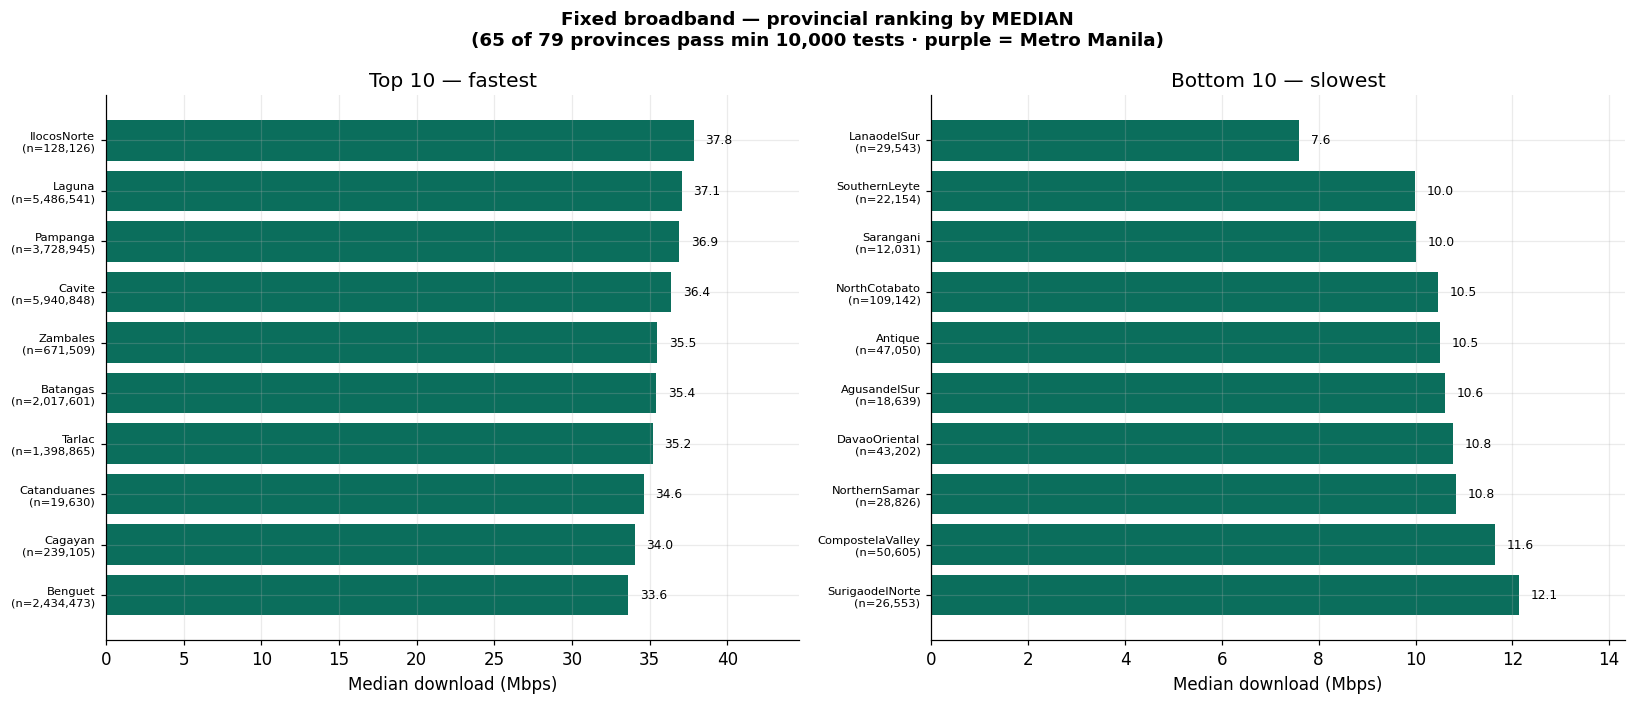

In [3]:
PROV_STATS = {}      # cache: one scan per network type, reused by both metrics

def province_stats(net_pred, net_key):
    """Per-province n / median / mean for one network type, filtered by MIN_TESTS."""
    if net_key not in PROV_STATS:
        d = q(f"""
            SELECT province,
                   COUNT(*)                     AS n,
                   MEDIAN(mean_throughput_mbps) AS med,
                   AVG(mean_throughput_mbps)    AS mean
            FROM t
            WHERE {net_pred} AND {DL} AND province IS NOT NULL
            GROUP BY 1
        """)
        PROV_STATS[net_key] = (d, d[d.n >= MIN_TESTS[net_key]].copy())
    return PROV_STATS[net_key]

def top_bottom_provinces(net_pred, net_key, seg_label, color, metric='med', topn=10):
    """Top-N and bottom-N provinces for one network type, ranked by `metric`
    ('med' or 'mean') — each metric gets its own figure so the two rankings
    can be compared side by side without being conflated in one chart."""
    d, kept = province_stats(net_pred, net_key)
    label = {'med': 'median', 'mean': 'mean'}[metric]
    ranked = kept.sort_values(metric).reset_index(drop=True)
    top, bot = ranked.tail(topn).iloc[::-1], ranked.head(topn)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
    for ax, part, ttl in [(axes[0], top, f'Top {topn} — fastest'),
                          (axes[1], bot, f'Bottom {topn} — slowest')]:
        p = part.iloc[::-1].reset_index(drop=True)      # best-of-panel at the top
        y = np.arange(len(p))
        cols = [C_AREA['Metro Manila'] if s == MANILA else color for s in p['province']]
        ax.barh(y, p[metric], color=cols)
        mx = p[metric].max()
        for yi, r in zip(y, p.itertuples()):
            ax.text(getattr(r, metric) + mx*0.02, yi, f'{getattr(r, metric):.1f}',
                    va='center', fontsize=8)
        ax.set_yticks(y)
        ax.set_yticklabels([f'{r.province}\n(n={r.n:,})' for r in p.itertuples()], fontsize=7.5)
        ax.set_xlim(0, mx*1.18)
        ax.set_xlabel(f'{label.capitalize()} download (Mbps)')
        ax.set_title(ttl)
    fig.suptitle(f'{seg_label} — provincial ranking by {label.upper()}\n'
                 f'({len(kept)} of {len(d)} provinces pass min {MIN_TESTS[net_key]:,} tests · '
                 f'purple = Metro Manila)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return ranked

fixed_by_median = top_bottom_provinces(FIXED, 'broadband', 'Fixed broadband', C_FIXED, metric='med')


### Fixed broadband — เรียงด้วย mean


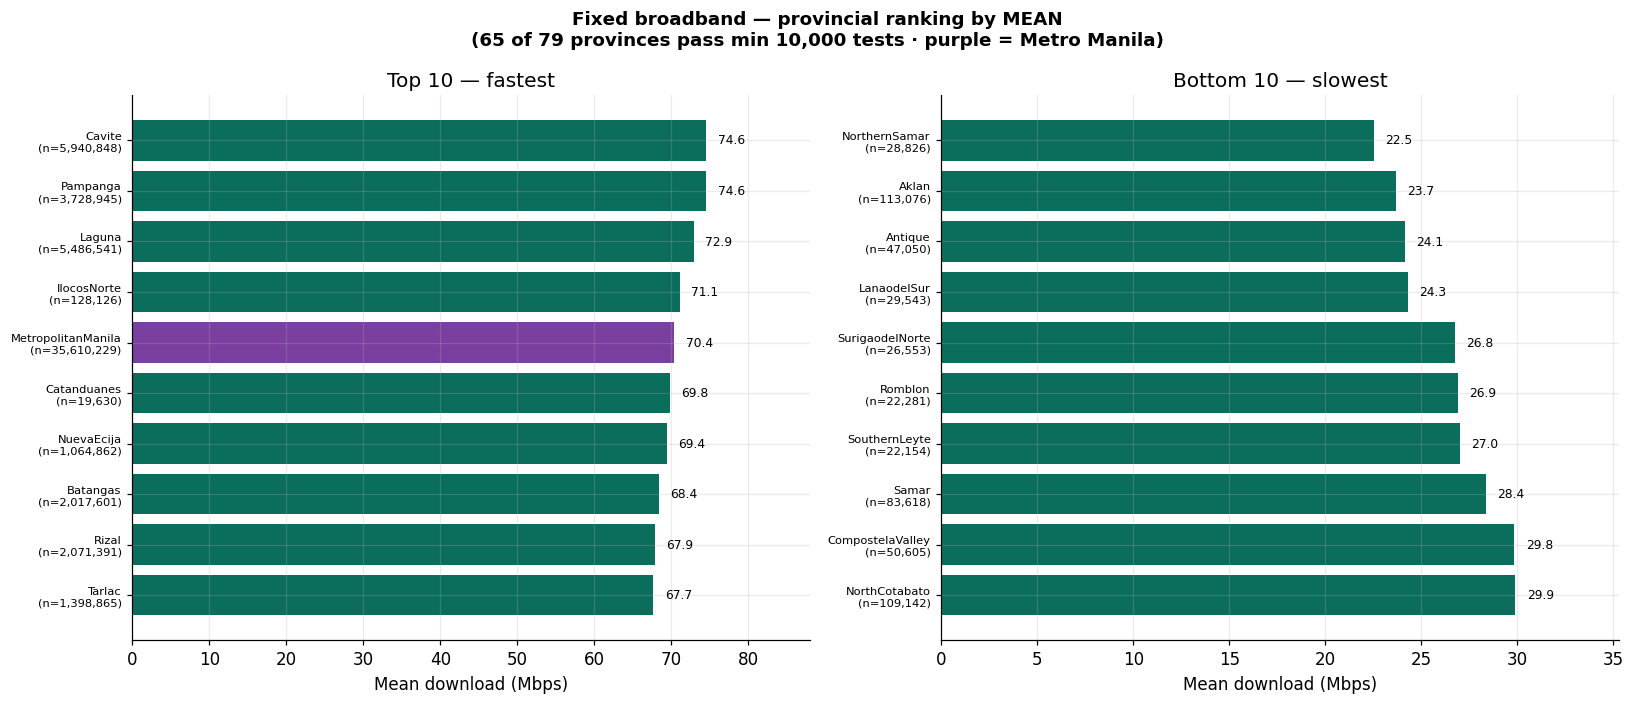

In [4]:
fixed_by_mean = top_bottom_provinces(FIXED, 'broadband', 'Fixed broadband', C_FIXED, metric='mean')


### Mobile — เรียงด้วย median

เกณฑ์ขั้นต่ำผ่อนเป็น 5,000 test เพราะข้อมูล mobile รายจังหวัดบางกว่า fixed มาก (median รายจังหวัด ~6,200 test เทียบกับ fixed ที่ ~113,000) — **จำนวนจังหวัดที่ผ่านเกณฑ์จึงน้อยกว่าฝั่ง fixed อย่างเห็นได้ชัด ให้อ่านหัวกราฟประกอบ**


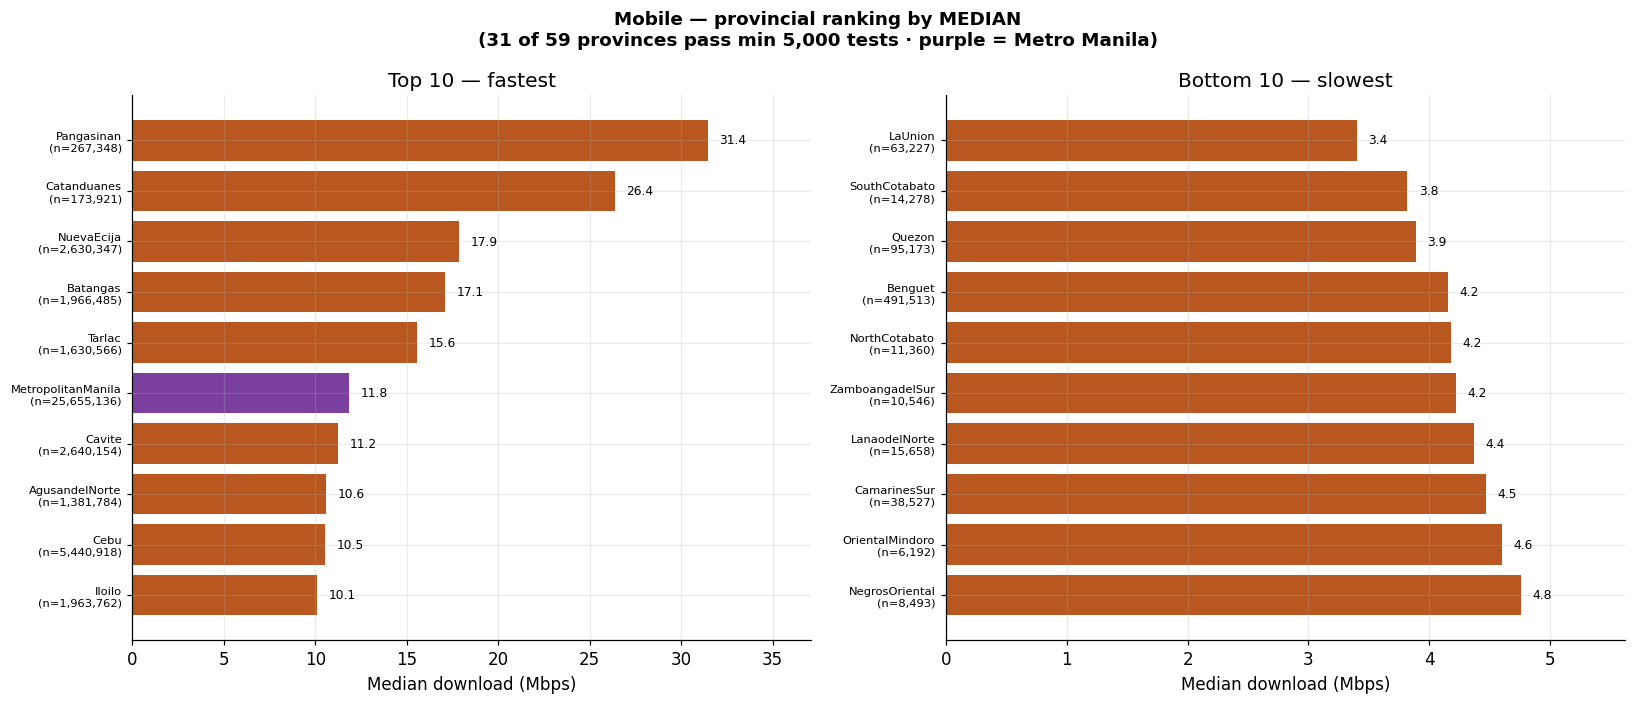

In [5]:
mobile_by_median = top_bottom_provinces(MOBILE, 'cellular', 'Mobile', C_MOBILE, metric='med')


### Mobile — เรียงด้วย mean


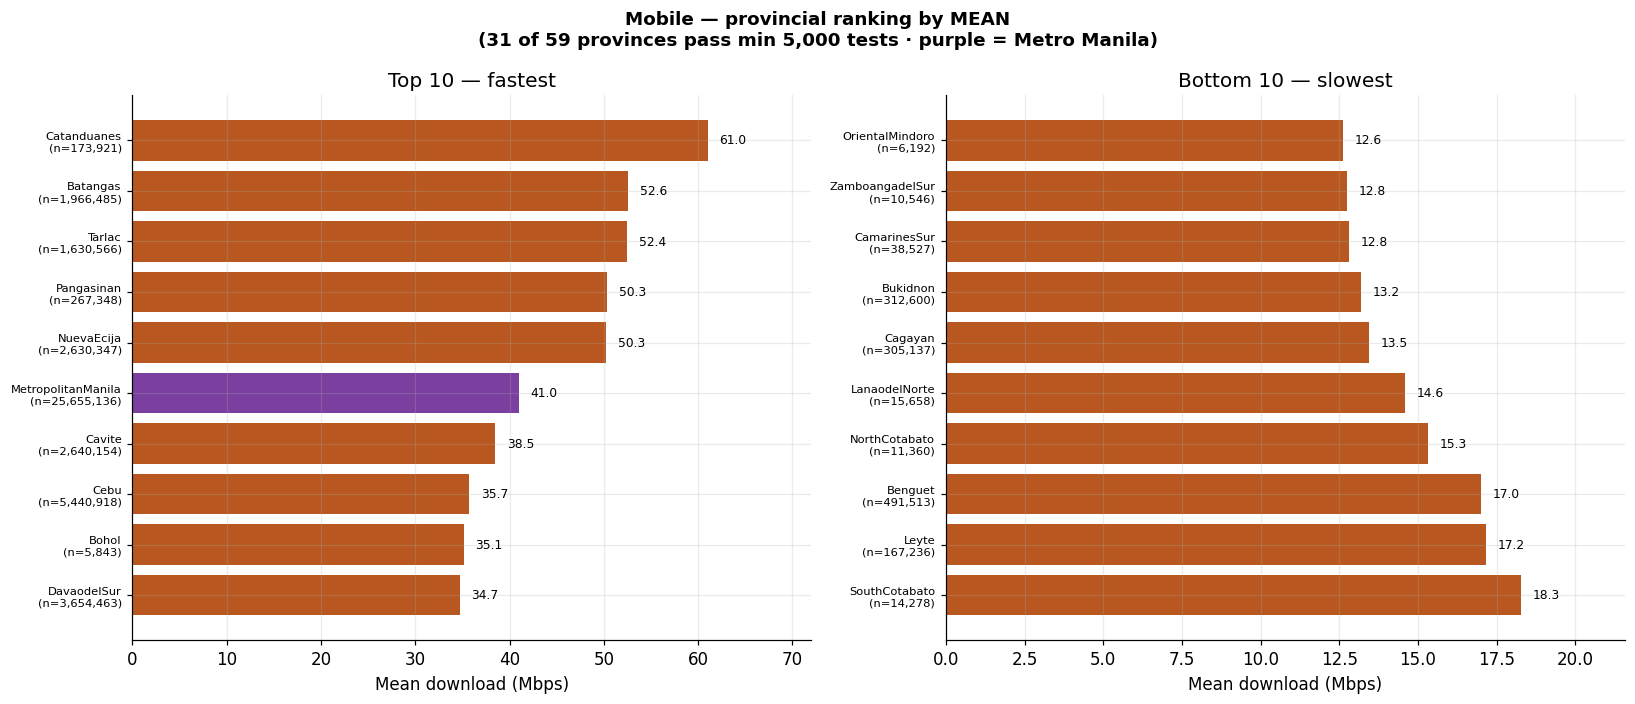

In [6]:
mobile_by_mean = top_bottom_provinces(MOBILE, 'cellular', 'Mobile', C_MOBILE, metric='mean')
